This notebook is a Work in Progress summary of the workflow and its tools

In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
import os
import numpy as np
import torch

In [2]:
from tools import smiles_to_graph

In [3]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'

Use PolyMetriX for datasets (with features)
https://github.com/lamalab-org/PolyMetriX

In [4]:
# Import necessary modules
from polymetrix.datasets import CuratedGlassTempDataset

# Load the dataset
dataset = CuratedGlassTempDataset()
print("Available features:", dataset.available_features)
print("Available labels:", dataset.available_labels)
print("Available metadata:", dataset.meta_info)

Available features: ['sidechainlevel.features.num_atoms_sidechainfeaturizer_sum', 'sidechainlevel.features.num_atoms_sidechainfeaturizer_mean', 'sidechainlevel.features.num_atoms_sidechainfeaturizer_max', 'sidechainlevel.features.num_atoms_sidechainfeaturizer_min', 'sidechainlevel.features.numsidechainfeaturizer', 'sidechainlevel.features.sidechainlength_to_star_attachment_distance_ratio_mean', 'sidechainlevel.features.sidechainlength_to_star_attachment_distance_ratio_min', 'sidechainlevel.features.sidechainlength_to_star_attachment_distance_ratio_max', 'sidechainlevel.features.sidechainlength_to_star_attachment_distance_ratio_sum', 'sidechainlevel.features.star_to_sidechain_min_distance_mean', 'sidechainlevel.features.star_to_sidechain_min_distance_min', 'sidechainlevel.features.star_to_sidechain_min_distance_max', 'sidechainlevel.features.star_to_sidechain_min_distance_sum', 'sidechainlevel.features.num_diverse_sidechains', 'sidechainlevel.features.balaban_j_index_sidechainfeaturizer

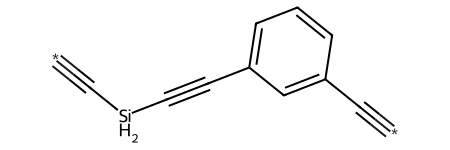

In [5]:
psmiles = dataset.psmiles[0]
pol = Chem.MolFromSmiles(psmiles)
pol

Transform a SMILES to a PyG graph

In [6]:
data = smiles_to_graph(Chem.MolToSmiles(pol))
print(data.x.shape, data.edge_index.shape, len(pol.GetAtoms()),len(pol.GetBonds()))

torch.Size([13, 9]) torch.Size([2, 26]) 13 13


In [7]:
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split

list_datas = []
for psmiles, exp_tg in zip(dataset.psmiles, dataset._labels):
    data = smiles_to_graph(psmiles)
    data.y = torch.tensor(exp_tg,dtype=torch.float32)
    data.to(device)
    list_datas.append(data)

N = len(list_datas)
train_size = int(0.8*N)
val_size = int(0.1*N)
test_size = N - train_size - val_size
train,val,test = random_split(list_datas,[train_size, val_size, test_size])

train_loader = DataLoader(train,batch_size=32,shuffle=True)
val_loader = DataLoader(val,batch_size=32)
test_loader = DataLoader(test,batch_size=32)

In [8]:
import torch
from torch import Tensor
from torch_geometric.nn import GCNConv, global_mean_pool, Linear
from torch.nn import ReLU


class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.head = Linear(out_channels,1)

    def forward(self, x: Tensor, edge_index: Tensor, batch: Tensor) -> Tensor:
        # x: Node feature matrix of shape [num_nodes, in_channels]
        # edge_index: Graph connectivity matrix of shape [2, num_edges]
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = global_mean_pool(x, batch)
        x = self.head(x)
        return x

model = GCN(9, 64, 32)

if os.path.exists("model.pt"):
    print("Model loaded from checkpoint")
    model.load_state_dict(torch.load("model.pt"))

model = model.to(device)

In [9]:
import time

learning_rate = 0.001
max_iters = 200
lowest_mse_loss = np.inf

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
mseloss = torch.nn.MSELoss()
maeloss = torch.nn.L1Loss()

# Save the train_loss and val_loss during training
train_loss_list = []
val_loss_list = []

start_training_time = time.perf_counter() 
for iter in range(max_iters):
    # Training
    total_loss = 0
    for batch_data in train_loader:
        optimizer.zero_grad(set_to_none=True)
        out = model(batch_data.x, batch_data.edge_index, batch_data.batch)
        loss = mseloss(out,batch_data.y.reshape(-1,1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    # Evaluation
    model.eval()
    mse_loss = 0
    mae_loss = 0
    with torch.no_grad():
        for batch_data in val_loader:
            out = model(batch_data.x, batch_data.edge_index, batch_data.batch)
            mse_loss += mseloss(out,batch_data.y.reshape(-1,1)).item()
            mae_loss += maeloss(out,batch_data.y.reshape(-1,1)).item()

    if mse_loss < lowest_mse_loss:
        lowest_mse_loss = mse_loss
        torch.save(model.state_dict(),"model.pt")

    train_loss = total_loss/len(train_loader)
    val_loss = mse_loss/len(val_loader)
    print(f"Epoch {iter} | Loss train: {train_loss:.4f} | Loss val: {val_loss:.4f} | RMSE val: {(val_loss)**0.5:.4f} | MAE val: {mae_loss/len(val_loader):.4f}")
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    model.train()
    
total_time = time.perf_counter() - start_training_time
print(f"Total time elapsed: {total_time:.4f} seconds.")
    

Epoch 0 | Loss train: 148439.8982 | Loss val: 59150.3071 | RMSE val: 243.2084 | MAE val: 219.2360
Epoch 1 | Loss train: 17395.6073 | Loss val: 9863.9061 | RMSE val: 99.3172 | MAE val: 82.5932
Epoch 2 | Loss train: 9972.9252 | Loss val: 9083.1551 | RMSE val: 95.3056 | MAE val: 79.0597
Epoch 3 | Loss train: 9169.1203 | Loss val: 8327.2830 | RMSE val: 91.2539 | MAE val: 75.4139
Epoch 4 | Loss train: 8404.3700 | Loss val: 7548.6417 | RMSE val: 86.8829 | MAE val: 71.4920
Epoch 5 | Loss train: 7641.3865 | Loss val: 6862.8847 | RMSE val: 82.8425 | MAE val: 67.7579
Epoch 6 | Loss train: 7007.9287 | Loss val: 6272.9573 | RMSE val: 79.2020 | MAE val: 64.6226
Epoch 7 | Loss train: 6447.6182 | Loss val: 5793.7642 | RMSE val: 76.1168 | MAE val: 62.0913
Epoch 8 | Loss train: 6017.7277 | Loss val: 5449.1024 | RMSE val: 73.8180 | MAE val: 60.0841
Epoch 9 | Loss train: 5763.6649 | Loss val: 5227.7435 | RMSE val: 72.3031 | MAE val: 58.5238
Epoch 10 | Loss train: 5581.1517 | Loss val: 5071.8796 | RMSE va

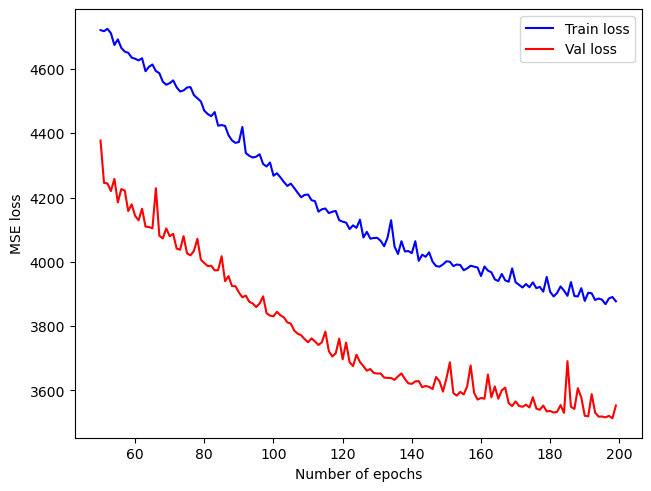

In [10]:
import matplotlib.pyplot as plt
start_iter = 50
fig, ax = plt.subplots(layout='constrained')
x = np.arange(start_iter,max_iters,1)
color = "blue"
ax.plot(x, train_loss_list[start_iter:], color = color, label = 'Train loss')
color = "red"
ax.plot(x, val_loss_list[start_iter:], color = color, label = 'Val loss')
ax.set_xlabel("Number of epochs")
ax.set_ylabel("MSE loss")
ax.legend()
plt.show()

Add a evaluation on the test set

In [11]:
model = GCN(9,64,32)
model.load_state_dict(torch.load("model.pt"))

model.eval()
mse_loss = 0
mae_loss = 0
with torch.no_grad():
    for batch_data in test_loader:
        out = model(batch_data.x, batch_data.edge_index, batch_data.batch)
        mse_loss += mseloss(out,batch_data.y.reshape(-1,1)).item()
        mae_loss += maeloss(out,batch_data.y.reshape(-1,1)).item()

print(f"RMSE test: {(mse_loss/len(test_loader))**0.5:.4f} | MAE test: {mae_loss/len(test_loader):.4f}")

RMSE test: 57.1118 | MAE test: 45.0390


In [12]:
print(f"Total number of parameters : {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Total number of parameters : 2753
